<a href="https://colab.research.google.com/github/anmolanand0207-cpu/Multi-region-Inventory-/blob/main/Multi_Region_Inventory_Analysis_pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

df = pd.read_csv("/content/supply_chain_data.csv")
#Intial data undestanding
print(df.shape)
df.info()
df.describe()

df.isnull()
df.duplicated()
#arranging col_name-
df.columns = (df.columns.str.strip().str.replace(' ','_').str.lower())


df['location'].value_counts() #No of unique locations in which this business is operating



(100, 24)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Product type             100 non-null    object 
 1   SKU                      100 non-null    object 
 2   Price                    100 non-null    float64
 3   Availability             100 non-null    int64  
 4   Number of products sold  100 non-null    int64  
 5   Revenue generated        100 non-null    float64
 6   Customer demographics    100 non-null    object 
 7   Stock levels             100 non-null    int64  
 8   Lead times               100 non-null    int64  
 9   Order quantities         100 non-null    int64  
 10  Shipping times           100 non-null    int64  
 11  Shipping carriers        100 non-null    object 
 12  Shipping costs           100 non-null    float64
 13  Supplier name            100 non-null    object 
 14  Location         

,count
location,
Kolkata,25
Mumbai,22
Chennai,20
Bangalore,18
Delhi,15


Before Further anlaysing data, i am making following assumptions in the dataset for calcualtion and inference purpose-


In [ ]:
PERIOD_DAYS   = 365
DEMAND_CV     = 0.30    # ASSUMPTION: std-dev of daily demand = 30% of mean (no time series in data)
ORDER_COST    = 50
SERVICE_LEVEL = {"A": 0.98, "B": 0.95, "C": 0.90}   # ASSUMPTION: higher service for high-value SKUs
CARRY_RATE    = {"Mumbai": .28, "Delhi": .26, "Bangalore": .25, "Chennai": .24, "Kolkata": .22}
                        # ASSUMPTION: annual carrying cost % of unit cost by city (rent, capital, handling differ)
BUDGET_SHARE  = 0.50  # only 50% of the cash needed for all reorders is currently available

In [ ]:
#Initial Screening of Dataset:-
print("Duplicate SKUs :", int(df.sku.duplicated().sum()))
print("Zero-stock SKUs:", int((df.stock_levels == 0).sum()))


Duplicate SKUs : 0
Zero-stock SKUs: 1


In [ ]:
#Important pre anlayis questions:-
df["revenue_calc"] = df.price * df.number_of_products_sold
print("\nCorr(revenue_generated, price x units):", round(df.revenue_generated.corr(df.revenue_calc), 2))
# 2) Selling price below manufacturing cost?
neg = (df.price < df.manufacturing_costs).sum()
print(f"SKUs priced BELOW unit manufacturing cost: {neg} of {len(df)}")
# 3) Three different 'lead time' columns
print("\nLead-time columns are uncorrelated with each other:")
print(df[["lead_times", "lead_time", "manufacturing_lead_time", "shipping_times"]].corr().round(2))




Corr(revenue_generated, price x units): 0.07
SKUs priced BELOW unit manufacturing cost: 44 of 100

Lead-time columns are uncorrelated with each other:
                         lead_times  lead_time  manufacturing_lead_time  \
lead_times                     1.00      -0.00                     0.00   
lead_time                     -0.00       1.00                     0.03   
manufacturing_lead_time        0.00       0.03                     1.00   
shipping_times                -0.05      -0.02                    -0.02   

                         shipping_times  
lead_times                        -0.05  
lead_time                         -0.02  
manufacturing_lead_time           -0.02  
shipping_times                     1.00  


Since revenue_generated deos not recoincle with price and units cross metrics and around 44% of SKUs sell below manufacturing cost.

           Hence, for further analysis i will use only cost-based metrics which do not depend on the revenue column.

 Furthermore, 3 lead_times has unclear meaning. So, let replenishment time L = lead_times (supplier order lead time) + shipping_times.

In [ ]:
#Creating new columns-

df["unit_cost"]        = df.manufacturing_costs
df["annual_demand"]    = df.number_of_products_sold * 365 / PERIOD_DAYS
df["daily_demand"]     = df.annual_demand / 365
df["sigma_daily"]      = DEMAND_CV * df.daily_demand
df["lead_days"]        = df.lead_times + df.shipping_times               # replenishment lead time L
df["carry_rate"]       = df.location.map(CARRY_RATE)
df["holding_cost"]     = df.carry_rate * df.unit_cost                    # H per unit per year
df["inventory_value"]  = df.stock_levels * df.unit_cost
df["cogs"]             = df.annual_demand * df.unit_cost
df["days_of_cover"]    = np.where(df.daily_demand > 0, df.stock_levels / df.daily_demand, np.nan)
df["sku_dio"]          = df.days_of_cover                                # inventory / (COGS/365), unit cost cancels out
df["carry_cost_annual"]= df.inventory_value * df.carry_rate
df[["sku","location","stock_levels","daily_demand","lead_days","unit_cost","inventory_value","days_of_cover"]].head()

,sku,location,stock_levels,daily_demand,lead_days,unit_cost,inventory_value,days_of_cover
0,SKU0,Mumbai,58,2.197260,11,46.279879,2684.232996,26.396509
1,SKU1,Mumbai,53,2.016438,32,33.616769,1781.688755,26.283967
2,SKU2,Mumbai,1,0.021918,12,30.688019,30.688019,45.625000
3,SKU3,Kolkata,23,0.227397,19,35.624741,819.369052,101.144578
4,SKU4,Delhi,5,2.386301,11,92.065161,460.325803,2.095293


Now I will analyse all 4 locations base don the metrics/features created above to microanlayse the situation of each location to take informed decisions:-


In [ ]:
region = df.groupby("location").agg(
    skus=("sku","count"), units_in_stock=("stock_levels","sum"), units_sold=("number_of_products_sold","sum"),
    inventory_value=("inventory_value","sum"), cogs=("cogs","sum"), carry_cost=("carry_cost_annual","sum"))
region["share_of_stock_%"]  = (100*region.units_in_stock/region.units_in_stock.sum()).round(1)
region["share_of_demand_%"] = (100*region.units_sold/region.units_sold.sum()).round(1)
region["stock_minus_demand_share_pp"] = region["share_of_stock_%"] - region["share_of_demand_%"]
region.round(0).sort_values("inventory_value", ascending=False)

,skus,units_in_stock,units_sold,inventory_value,cogs,carry_cost,share_of_stock_%,share_of_demand_%,stock_minus_demand_share_pp
location,,,,,,,,,
Kolkata,25,1439,12770,66220.0,556035.0,14568.0,30.0,28.0,2.0
Bangalore,18,856,5420,50811.0,359916.0,12703.0,18.0,12.0,6.0
Chennai,20,799,8768,45518.0,426580.0,10924.0,17.0,19.0,-2.0
Mumbai,22,932,9426,34087.0,365037.0,9544.0,20.0,20.0,-1.0
Delhi,15,751,9715,32150.0,501262.0,8359.0,16.0,21.0,-5.0


A positive `stock_minus_demand_share_pp` means the region holds a bigger share of inventory than its share of demand: a candidate for slowing replenishment. Negative means it is under-stocked relative to demand.

,skus,annual_cogs,inventory_value,skus_%,cogs_%,inv_value_%
abc,,,,,,
A,43,1765532.0,145575.0,43.0,80.0,64.0
B,23,331258.0,44492.0,23.0,15.0,19.0
C,34,112040.0,38718.0,34.0,5.0,17.0


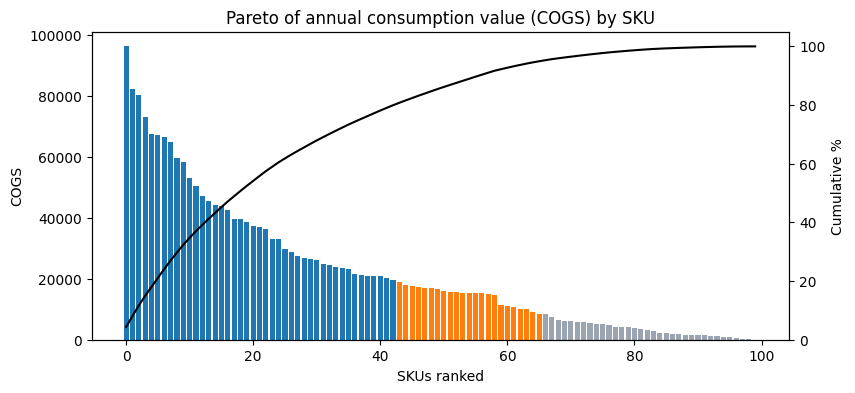

In [ ]:
#ABC ANALYSIS:-
df = df.sort_values("cogs", ascending=False).reset_index(drop=True)
df["cum_share"] = df.cogs.cumsum() / df.cogs.sum()
df["abc"] = np.where(df.cum_share <= 0.80, "A", np.where(df.cum_share <= 0.95, "B", "C"))
abc = df.groupby("abc").agg(skus=("sku","count"), annual_cogs=("cogs","sum"), inventory_value=("inventory_value","sum"))
abc["skus_%"]  = (100*abc.skus/abc.skus.sum()).round(1)
abc["cogs_%"]  = (100*abc.annual_cogs/abc.annual_cogs.sum()).round(1)
abc["inv_value_%"] = (100*abc.inventory_value/abc.inventory_value.sum()).round(1)
display(abc.round(0))

fig, ax = plt.subplots(figsize=(9,4))
ax.bar(range(len(df)), df.cogs, color=df.abc.map({"A":"#1f77b4","B":"#ff7f0e","C":"#9aa5b1"}))
ax2 = ax.twinx(); ax2.plot(range(len(df)), df.cum_share*100, color="black"); ax2.set_ylim(0,105)
ax.set_title("Pareto of annual consumption value (COGS) by SKU"); ax.set_xlabel("SKUs ranked"); ax.set_ylabel("COGS"); ax2.set_ylabel("Cumulative %")
plt.show()

In [ ]:
z = df.abc.map(SERVICE_LEVEL).map(norm.ppf)
df["eoq"]            = np.sqrt(2 * df.annual_demand * ORDER_COST / df.holding_cost)
df["safety_stock"]   = z * df.sigma_daily * np.sqrt(df.lead_days)
df["reorder_point"]  = df.daily_demand * df.lead_days + df.safety_stock
df["max_level"]      = df.safety_stock + df.eoq          # peak on-hand right after a delivery

tc = lambda Q: df.annual_demand/Q*ORDER_COST + Q/2*df.holding_cost       # ordering + holding cost per year
df["order_qty_now"]  = df.order_quantities.clip(lower=1)
df["tc_current_Q"]   = tc(df.order_qty_now)
df["tc_eoq"]         = tc(df.eoq)
df["eoq_saving"]     = df.tc_current_Q - df.tc_eoq

print(f"Annual ordering+holding cost with current order quantities: {df.tc_current_Q.sum():,.0f}")
print(f"Annual ordering+holding cost with EOQ                    : {df.tc_eoq.sum():,.0f}")
print(f"Potential saving: {df.eoq_saving.sum():,.0f}  ({100*df.eoq_saving.sum()/df.tc_current_Q.sum():.1f}%)")
print("Share of saving from the 10 SKUs with the worst order quantities:", f"{100*df.eoq_saving.nlargest(10).sum()/df.eoq_saving.sum():.0f}%")
df[["sku","location","abc","annual_demand","eoq","order_qty_now","safety_stock","reorder_point","stock_levels"]].head(8).round(1)

Annual ordering+holding cost with current order quantities: 156,208
Annual ordering+holding cost with EOQ                    : 64,879
Potential saving: 91,328  (58.5%)
Share of saving from the 10 SKUs with the worst order quantities: 81%


,sku,location,abc,annual_demand,eoq,order_qty_now,safety_stock,reorder_point,stock_levels
0,SKU10,Kolkata,A,996.0,68.5,80,6.5,47.4,51
1,SKU40,Kolkata,A,933.0,69.3,39,8.3,79.9,90
2,SKU4,Delhi,A,871.0,60.3,56,4.9,31.1,5
3,SKU74,Delhi,A,904.0,65.7,1,5.1,32.3,41
4,SKU78,Mumbai,A,946.0,68.9,51,4.8,28.1,5
5,SKU80,Chennai,A,872.0,68.7,41,5.9,44.1,39
6,SKU46,Chennai,A,859.0,68.0,6,8.8,95.9,92
7,SKU83,Bangalore,A,663.0,52.1,7,6.3,64.5,65


status
Stockout        1
Reorder now    31
Healthy        41
Overstock      27
Name: count, dtype: int64

Excess stock value: 54,761  =  23.9% of total inventory value


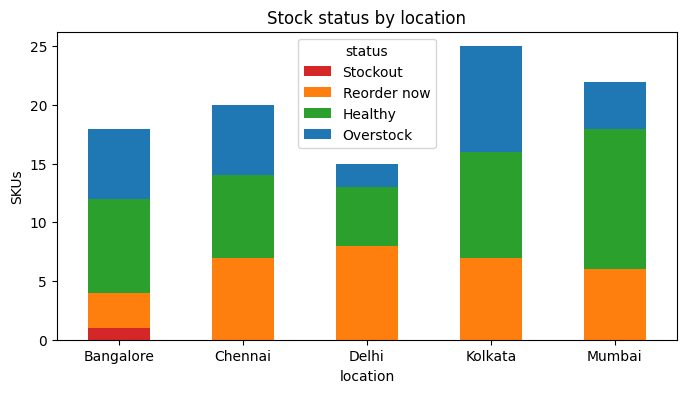

In [ ]:
def status(r):
    if r.stock_levels == 0:                 return "Stockout"
    if r.stock_levels <= r.reorder_point:   return "Reorder now"
    if r.stock_levels > r.max_level:        return "Overstock"
    return "Healthy"
df["status"] = df.apply(status, axis=1)
df["excess_units"] = (df.stock_levels - df.max_level).clip(lower=0)
df["excess_value"] = df.excess_units * df.unit_cost
df["shortfall_units"] = (df.reorder_point - df.stock_levels).clip(lower=0)

order = ["Stockout","Reorder now","Healthy","Overstock"]
print(df.status.value_counts().reindex(order).fillna(0).astype(int))
print(f"\nExcess stock value: {df.excess_value.sum():,.0f}  =  {100*df.excess_value.sum()/df.inventory_value.sum():.1f}% of total inventory value")

ct = pd.crosstab(df.location, df.status).reindex(columns=order, fill_value=0)
ct.plot(kind="bar", stacked=True, figsize=(8,4), color=["#d62728","#ff7f0e","#2ca02c","#1f77b4"])
plt.title("Stock status by location"); plt.ylabel("SKUs"); plt.xticks(rotation=0); plt.show()

In [ ]:
# The paradox that matters: the same region can be over-stocked on some SKUs and short on others.
# capital_offset_potential = cash that correcting overstock could free to fund that region's shortfalls
paradox = df.groupby("location").apply(lambda g: pd.Series({
    "excess_value": g.excess_value.sum(),
    "shortfall_value": (g.shortfall_units*g.unit_cost).sum(),
    "capital_offset_potential": min(g.excess_value.sum(), (g.shortfall_units*g.unit_cost).sum())}), include_groups=False)
paradox.round(0)

,excess_value,shortfall_value,capital_offset_potential
location,,,
Bangalore,15832.0,3056.0,3056.0
Chennai,10441.0,6776.0,6776.0
Delhi,5666.0,11991.0,5666.0
Kolkata,17440.0,5637.0,5637.0
Mumbai,5381.0,5160.0,5160.0


Network DIO: 37.8 days | turnover 9.7x | annual carrying cost 56,099


,inventory_value,cogs,carry_cost,excess_value,DIO_days,turnover,carry_cost_%_of_inv,excess_%_of_inv
location,,,,,,,,
Bangalore,50810.7,359916.5,12702.7,15832.5,51.5,7.1,25.0,31.2
Kolkata,66220.4,556035.3,14568.5,17440.5,43.5,8.4,22.0,26.3
Chennai,45517.6,426580.1,10924.2,10441.2,38.9,9.4,24.0,22.9
Mumbai,34086.7,365037.1,9544.3,5381.2,34.1,10.7,28.0,15.8
Delhi,32149.8,501261.6,8359.0,5666.0,23.4,15.6,26.0,17.6


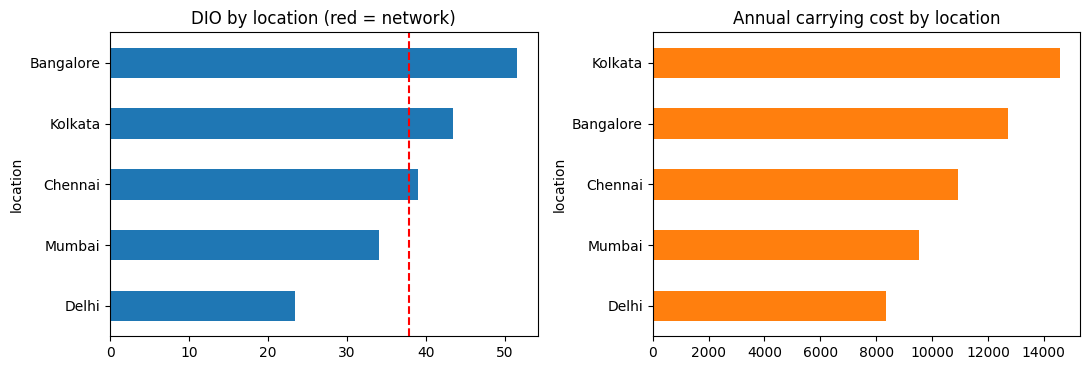

In [ ]:
reg = df.groupby("location").agg(inventory_value=("inventory_value","sum"), cogs=("cogs","sum"),
                                 carry_cost=("carry_cost_annual","sum"), excess_value=("excess_value","sum"))
reg["DIO_days"]        = 365 * reg.inventory_value / reg.cogs
reg["turnover"]        = reg.cogs / reg.inventory_value
reg["carry_cost_%_of_inv"] = 100 * reg.carry_cost / reg.inventory_value
reg["excess_%_of_inv"] = 100 * reg.excess_value / reg.inventory_value
total_dio = 365 * df.inventory_value.sum() / df.cogs.sum()
print(f"Network DIO: {total_dio:.1f} days | turnover {365/total_dio:.1f}x | annual carrying cost {df.carry_cost_annual.sum():,.0f}")
display(reg.round(1).sort_values("DIO_days", ascending=False))

fig, ax = plt.subplots(1,2, figsize=(11,3.8))
reg.DIO_days.sort_values().plot(kind="barh", ax=ax[0], color="#1f77b4"); ax[0].axvline(total_dio, color="red", ls="--"); ax[0].set_title("DIO by location (red = network)")
reg.carry_cost.sort_values().plot(kind="barh", ax=ax[1], color="#ff7f0e"); ax[1].set_title("Annual carrying cost by location")
plt.tight_layout(); plt.show()

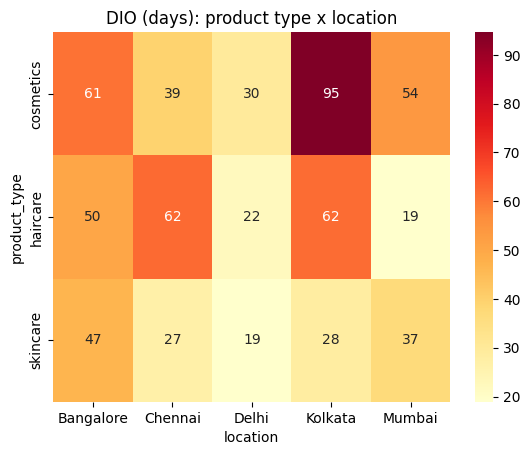

In [ ]:
# DIO by product type x location (heatmap)
pt = df.groupby(["product_type","location"]).apply(lambda g: 365*g.inventory_value.sum()/g.cogs.sum(), include_groups=False).unstack()
sns.heatmap(pt, annot=True, fmt=".0f", cmap="YlOrRd"); plt.title("DIO (days): product type x location"); plt.show()

In [ ]:
sup = df.groupby("supplier_name").agg(skus=("sku","count"), avg_lead_days=("lead_days","mean"),
        avg_defect_pct=("defect_rates","mean"), inspection_fail_pct=("inspection_results", lambda s: 100*(s=="Fail").mean()),
        inventory_value=("inventory_value","sum"), stockout_or_reorder=("status", lambda s: s.isin(["Stockout","Reorder now"]).sum()))
display(sup.round(1).sort_values("inspection_fail_pct", ascending=False))

mode = df.groupby("transportation_modes").agg(skus=("sku","count"), avg_ship_days=("shipping_times","mean"),
        avg_ship_cost=("shipping_costs","mean"), avg_route_cost=("costs","mean"))
display(mode.round(2))

,skus,avg_lead_days,avg_defect_pct,inspection_fail_pct,inventory_value,stockout_or_reorder
supplier_name,,,,,,
Supplier 4,18,22.6,2.3,66.7,68400.1,3
Supplier 5,18,20.9,2.7,38.9,37777.5,4
Supplier 2,22,21.7,2.4,36.4,39914.9,10
Supplier 1,27,22.9,1.8,22.2,52767.6,9
Supplier 3,15,19.5,2.5,20.0,29925.1,6


,skus,avg_ship_days,avg_ship_cost,avg_route_cost
transportation_modes,,,,
Air,26,5.12,6.02,561.71
Rail,28,6.57,5.47,541.75
Road,29,4.72,5.54,553.39
Sea,17,7.12,4.97,417.82


In [ ]:
need = df[df.status.isin(["Stockout","Reorder now"])].copy()
need["order_qty"]  = np.ceil(np.maximum(need.eoq, need.shortfall_units)).astype(int)
need["order_cost"] = need.order_qty * need.unit_cost
need["abc_rank"]   = need.abc.map({"A":0,"B":1,"C":2})
need = need.sort_values(["abc_rank","days_of_cover"]).reset_index(drop=True)   # A-class and lowest cover first
budget = BUDGET_SHARE * need.order_cost.sum()
need["cum_cost"] = need.order_cost.cumsum()
need["funded"]   = need.cum_cost <= budget
print(f"Cash needed for all reorders: {need.order_cost.sum():,.0f} | budget: {budget:,.0f}")
print(f"Funded {need.funded.sum()} of {len(need)} SKUs; A-class funded: {need[need.abc=='A'].funded.mean()*100:.0f}%")
need[["sku","location","abc","stock_levels","days_of_cover","order_qty","order_cost","funded"]].head(12).round(1)

Cash needed for all reorders: 103,702 | budget: 51,851
Funded 12 of 32 SKUs; A-class funded: 67%


,sku,location,abc,stock_levels,days_of_cover,order_qty,order_cost,funded
0,SKU78,Mumbai,A,5,1.9,69,4907.7,True
1,SKU4,Delhi,A,5,2.1,61,5616.0,True
2,SKU16,Bangalore,A,2,2.6,39,3007.1,True
3,SKU58,Delhi,A,10,4.1,73,4748.5,True
4,SKU44,Delhi,A,13,5.2,126,2841.8,True
5,SKU9,Chennai,A,14,5.2,93,4460.1,True
6,SKU66,Kolkata,A,13,6.7,88,3703.4,True
7,SKU36,Delhi,A,18,6.8,91,4143.4,True
8,SKU15,Bangalore,A,9,7.0,44,4273.3,True
9,SKU95,Mumbai,A,15,8.1,64,3769.0,True


It is a simple greedy rule (A-class first, then lowest days of cover)

In [ ]:
#Sensitivity - Fragile and Cocnlusiosn
rows = []
for cv in [0.2, 0.3, 0.5]:
    for S in [25, 50, 100]:
        z_ = df.abc.map(SERVICE_LEVEL).map(norm.ppf)
        ss = z_*cv*df.daily_demand*np.sqrt(df.lead_days)
        rop = df.daily_demand*df.lead_days + ss
        eoq = np.sqrt(2*df.annual_demand*S/df.holding_cost)
        rows.append({"demand_CV":cv, "order_cost":S,
                     "reorder_or_stockout_SKUs": int((df.stock_levels <= rop).sum()),
                     "overstock_SKUs": int((df.stock_levels > ss+eoq).sum()),
                     "safety_stock_value": round((ss*df.unit_cost).sum())})
sens = pd.DataFrame(rows); sens

,demand_CV,order_cost,reorder_or_stockout_SKUs,overstock_SKUs,safety_stock_value
0,0.2,25,32,50,10682
1,0.2,50,32,29,10682
2,0.2,100,32,18,10682
3,0.3,25,32,49,16024
4,0.3,50,32,28,16024
5,0.3,100,32,18,16024
6,0.5,25,37,48,26706
7,0.5,50,37,28,26706
8,0.5,100,37,17,26706


Note: overstock counts here use stock > safety stock + EOQ only, so they can differ by one SKU from section 7, where a SKU already flagged as reorder-now is not also counted as overstock. Read this table before presenting: it shows which findings are stable (the ranking of regions) and which depend on assumptions (the exact count of SKUs to reorder).